In [5]:
import numpy as np
import os
import time
import math
import math
import random


In [2]:
def create_volume(outliers):
    true_mean = np.zeros((64, 64))
    true_std = np.zeros((64, 64))
    volume = np.zeros((5000, 64, 64))
    np.random.seed(1)
    for i in range(64):
        for j in range(64):
            s = np.random.normal(1, 1, 5000)
            #volume[i][j][k] = s
            for k in range(5000):
                
                volume[k][i][j] = s[k]
        # for o in range(500):
            true_mean[i][j] = np.mean(s)
            true_std[i][j] = np.std(s)
            
            #Add Outliers
            indicies = np.random.randint(0, 4999, outliers)
            for o in range(outliers):
                g = indicies[o]
                outs = np.random.uniform(0, 11)
                volume[g][i][j] = outs
                
    return volume, true_mean, true_std

In [2]:
np.shape(volume)

(5000, 64, 64)

In [ ]:
def algorithm(data, t):
    
    # Initialize variables for running stats
    n = 0      # Count of valid values
    mean = 0   # Running mean
    M2 = 0     # Sum of squares of differences from the current mean
    threshold = t  # Number of standard deviations to trim outliers

    # Loop through each value in the stream
    for value in data:
        # Outlier detection: only skip trimming for the first value
        if n > 1:
            # Calculate temporary standard deviation
            variance = M2 / (n - 1) if n > 1 else 0
            stddev = math.sqrt(variance)

            # Check if value is within threshold * stddev from the mean
            if abs(value - mean) > threshold * stddev:
                #print(f"Value {value} is considered an outlier and will be skipped.")
                continue

        # Update running statistics for non-outliers
        n += 1
        delta = value - mean
        mean += delta / n
        delta2 = value - mean
        M2 += delta * delta2

        # Compute the standard deviation for the current set
        if n < 2:
            stddev = float('nan')  # Stddev undefined for the first value
        else:
            variance = M2 / (n - 1)
            stddev = math.sqrt(variance)

        # Output the running mean and standard deviation after each valid value
        #print(f"After {n} valid values: Mean = {mean}, Stddev = {stddev}")
    return mean, stddev

In [3]:
def image_algorithm(volume, t):
    count_image = np.zeros((64, 64))
    mean_image = np.zeros((64, 64))
    sum_squared_image = np.zeros((64, 64))
    threshold = t
    for i in range(5000):
        for j in range(64):
            for k in range(64):
                n = count_image[j][k]      # Count of valid values
                mean = mean_image[j][k]   # Running mean
                M2 = sum_squared_image[j][k]
                value = volume[i][j][k]
                if n > 1:

                    
                    # Calculate temporary standard deviation
                    variance = M2  / (n - 1) if n > 1 else 0
                    stddev = math.sqrt(variance)

                    # Check if value is within threshold * stddev from the mean
                    if abs(value - mean) > threshold * stddev:
                        #print(f"Value {value} is considered an outlier and will be skipped.")
                        continue

                # Update running statistics for non-outliers
                n += 1
                delta = value - mean
                mean += delta / n
                delta2 = value - mean
                M2 += delta * delta2

                # Compute the standard deviation for the current set
                if n < 2:
                    stddev = float('nan')  # Stddev undefined for the first value
                else:
                    variance = M2 / (n - 1)
                    stddev = math.sqrt(variance)
                    
                    #Update Values
                count_image[j][k] = n     # Count of valid values
                mean_image[j][k] = mean  # Running mean
                sum_squared_image[j][k] = M2
                volume[i][j][k] = value
            
    std_image =  np.sqrt(sum_squared_image  / (count_image - 1))
    return mean_image, std_image


        


In [6]:
final = dict()
np.random.seed(1)
percent_mean_errors = []
percent_std_errors = []



volume, true_mean, true_std = create_volume(500)
mean, std = image_algorithm(volume, 3)
diff_in_means = mean - true_mean
diff_in_std = std - true_std
percent_mean_errors.append(abs(diff_in_means/true_mean) * 100)
percent_std_errors.append(abs(diff_in_std/ true_std) * 100)
    
    


In [8]:
np.mean(percent_mean_errors) 

4.568041762717893

In [9]:
np.mean(percent_std_errors)

2.1835305209481346

In [12]:
percent_mean_errors

[array([[ 4.07841638,  2.15910396, 29.82341015, ...,  5.10727422,
          3.21720396,  5.06579891],
        [ 4.87241718,  3.79940609,  4.58199898, ...,  4.45721586,
          4.44520577,  4.23857525],
        [ 3.55301688,  3.7658925 ,  4.46895091, ...,  4.22307924,
          3.58949023,  3.04372179],
        ...,
        [ 3.47053883,  2.62580723,  4.84623645, ...,  3.61002117,
          3.30890101,  2.06740278],
        [ 4.01973958,  3.67423445,  2.51738936, ...,  3.2914631 ,
          1.48240254,  3.89831954],
        [ 3.71306478,  4.2294923 ,  4.59235249, ...,  2.18299775,
          4.74007394,  4.04753673]])]

In [22]:
check = np.reshape(percent_mean_errors, (4096, 1))

In [23]:
vals = 0
for i in range(len(check)):
    if(check[i] > 10):
        print(i)
        print(check[i])
        vals +=1
        
        
        
        
vals

2
[29.82341015]
20
[11.95857837]
176
[76.39647821]
188
[133.21687623]
247
[108.15279267]
297
[16.44757509]
498
[176.4027634]
988
[14.78752161]
1086
[11.0906298]
1152
[18.40048551]
1506
[136.68179164]
1678
[10.38775368]
1704
[15.88347853]
1735
[44.86025916]
1749
[10.47254611]
1873
[59.62479745]
1923
[17.98678796]
2143
[12.76346354]
2363
[138.28641876]
2411
[57.41943083]
2416
[55.18027396]
2580
[11.96465566]
2618
[11.68086936]
2794
[13.76958847]
2871
[10.93753884]
2930
[36.58874856]
2941
[40.5834355]
2992
[14.57509791]
2998
[21.58903658]
3125
[47.49562843]
3142
[29.64436064]
3283
[89.9675745]
3339
[23.00901123]
3437
[11.41169141]
3572
[13.62119537]
3577
[10.12833374]
3623
[25.6592993]
4002
[562.98470916]


38

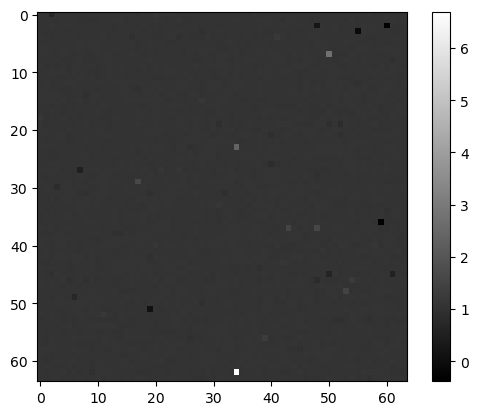

In [7]:
import matplotlib.pyplot as plt
plt.imshow(mean, cmap='gray')
plt.colorbar()

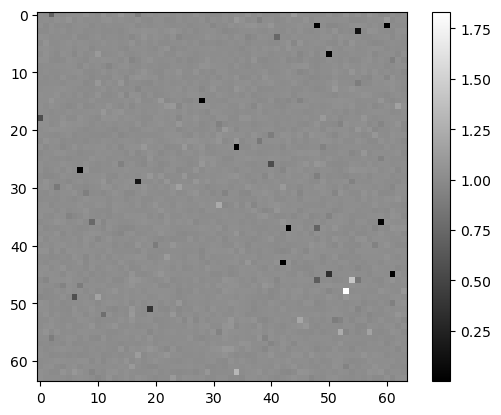

In [8]:
import matplotlib.pyplot as plt
plt.imshow(std, cmap='gray')
plt.colorbar()